# `Machine Learning project (group SEA, 13) -  Alkemy AI Productivity`
### **What happens to margins when AI enters business workflows?**

## Import of the libraries 

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno
from IPython.display import display, Markdown
from itertools import zip_longest
import warnings

In [185]:
warnings.filterwarnings('ignore')

## Upload of the dataset

In [158]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [159]:
df_productivity = pd.read_csv(PATH)

## First EDA

In [160]:
print("Dataset shape:", df_productivity.shape)

Dataset shape: (3248, 34)


In [161]:
print("--- INFO ---")
df_productivity.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sl

In [162]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()
bool_cols = df_productivity.select_dtypes(include=['bool', 'boolean']).columns.tolist()

# Create a Markdown table layout
md_text = f"""
| 🔢 Numerical ({len(num_cols)}) | 🔠 Categorical ({len(cat_cols)}) | 🔘 Boolean ({len(bool_cols)}) |
| :--- | :--- | :--- |
"""

# Zip all THREE lists together
for num, cat, b_col in zip_longest(num_cols, cat_cols, bool_cols, fillvalue=""):
    md_text += f"| {num} | {cat} | {b_col} |\n"

# Display the table
print("Columns Types:")
display(Markdown(md_text))

Columns Types:



| 🔢 Numerical (15) | 🔠 Categorical (18) | 🔘 Boolean (1) |
| :--- | :--- | :--- |
| task_complexity_score | task_id | ai_assisted |
| brief_quality_score | client |  |
| scope_change_flag | project_id |  |
| sla_days | client_tier |  |
| sla_breach | team |  |
| hours_spent | task_type |  |
| billable_hours | seniority |  |
| ai_usage_pct | deadline_pressure |  |
| revisions | pricing_model |  |
| errors | created_at |  |
| rework_hours | delivered_at |  |
| outcome_score | created_by |  |
| revenue | updated_at |  |
| cost | task_status |  |
| profit | workflow_stage |  |
|  | jira_ticket |  |
|  | legacy_ai_flag |  |
|  | content_version |  |


In [163]:
print("--- DESCRIPTIVE STATISTICS  ---")
df_productivity.describe()

--- DESCRIPTIVE STATISTICS  ---


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


### Dataset Overview and Descriptive Statistics
The dataset contains **3,248 observations** and **34 variables**, each observation representing a single task performed within a business workflow. The unit of analysis is at the task level, enabling a granular assessment of operational performance.
#### Data Types
Based on the info and exploratory steps executed, the 34 columns are categorized as follows:
- **15 Numerical variables** (e.g., `task_complexity_score`, `hours_spent`, `revenue`, `profit`)
- **18 Categorical variables** (e.g., `task_id`, `client`, `seniority`, `task_type`)
- **1 Boolean variable** (`ai_assisted`)                    

The variables encompass multiple dimensions of the workflow:
- **Operational efficiency**: `hours_spent` (mean: 13.06, max: 263.6), `billable_hours`, `sla_days` (mean: 5.01)
- **AI adoption**: `ai_usage_pct` (ranging from 0% to 93%), `ai_assisted`
- **Quality and process performance**: `revisions` (mean: 3.0), `errors` (mean: 1.01, max: 7), `rework_hours` (mean: 2.44, max: 57.5)
- **Economic outcomes**: `revenue` (mean: 1,120), `cost` (mean: 771), `profit`
---
### Descriptive Statistics Highlights
The summary statistics provide initial insights into the distribution and variability of key variables:
#### 1) Profit and Economic Outcomes
The average **profit** is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses, while others are highly lucrative (maximum ≈ 14006). A high standard deviation (≈ 888) reflects significant variability in profitability across tasks. Similarly, **revenue** is heavily right-skewed with a maximum of nearly 15,000 compared to a mean of 1,120.
#### 2) AI Usage
The average **AI usage** is approximately 36% (`ai_usage_pct`), missing in some records, with existing values ranging strictly from 0% to 93%. This continuous spectrum indicates that AI is not uniformly adopted across tasks but varies significantly in intensity. This enables the analysis of non-linear relationships and the identification of potential threshold effects.
#### 3) Time and Efficiency
The average **time spent** per task is roughly 13 hours, with a median of about 11 hours. Extreme outliers are present (maximum ≈ 263 hours), suggesting the existence of highly complex or delayed tasks. In addition, ~40% of the recorded tasks incurred an **SLA breach** (mean `sla_breach`: 0.398).
#### 4) Rework and Quality Performance
The average **rework time** is approximately 2.4 hours, but severely right-skewed with a maximum value exceeding 57 hours. This suggests that a small subset of tasks generates disproportionately high levels of rework, severely impacting efficiency. Task complexity scores and brief quality scores both hover around a mean of 3 on a 1-5 scale, indicating moderate difficulty and baseline quality on average.
---
### Data Quality Considerations
Several variables contain missing values. In 3,248 total rows, columns like `ai_usage_pct` (3,104 non-null), `rework_hours` (3,176 non-null), `billable_hours` (3,166 non-null), `outcome_score` (3,115 non-null), and `brief_quality_score` (3,179 non-null) show gaps. Rather than being solely technical issues, these missing entries may reflect real-world data collection limitations, unrecorded workflows, or process inefficiencies requiring careful imputation.
---
### Implications for Further Analysis
This descriptive phase highlights the following key directions:
1. **Heterogeneous Profitability**: The extreme variability in profit and rework hours motivates investigating exactly which conditions (e.g., `client_tier`, `task_type`) lead to losses versus high margins.
2. **AI Impact on Efficiency**: AI usage is recorded as a continuous percentage, allowing for deeply exploring its linear or non-linear effects on completion time (`hours_spent`) and quality (`errors`, `rework_hours`).
3. **Quality Instability**: Rework and SLA breaches are concentrated in specific tasks, representing clear points of leverage for process optimization.

#### Variables' Distributions

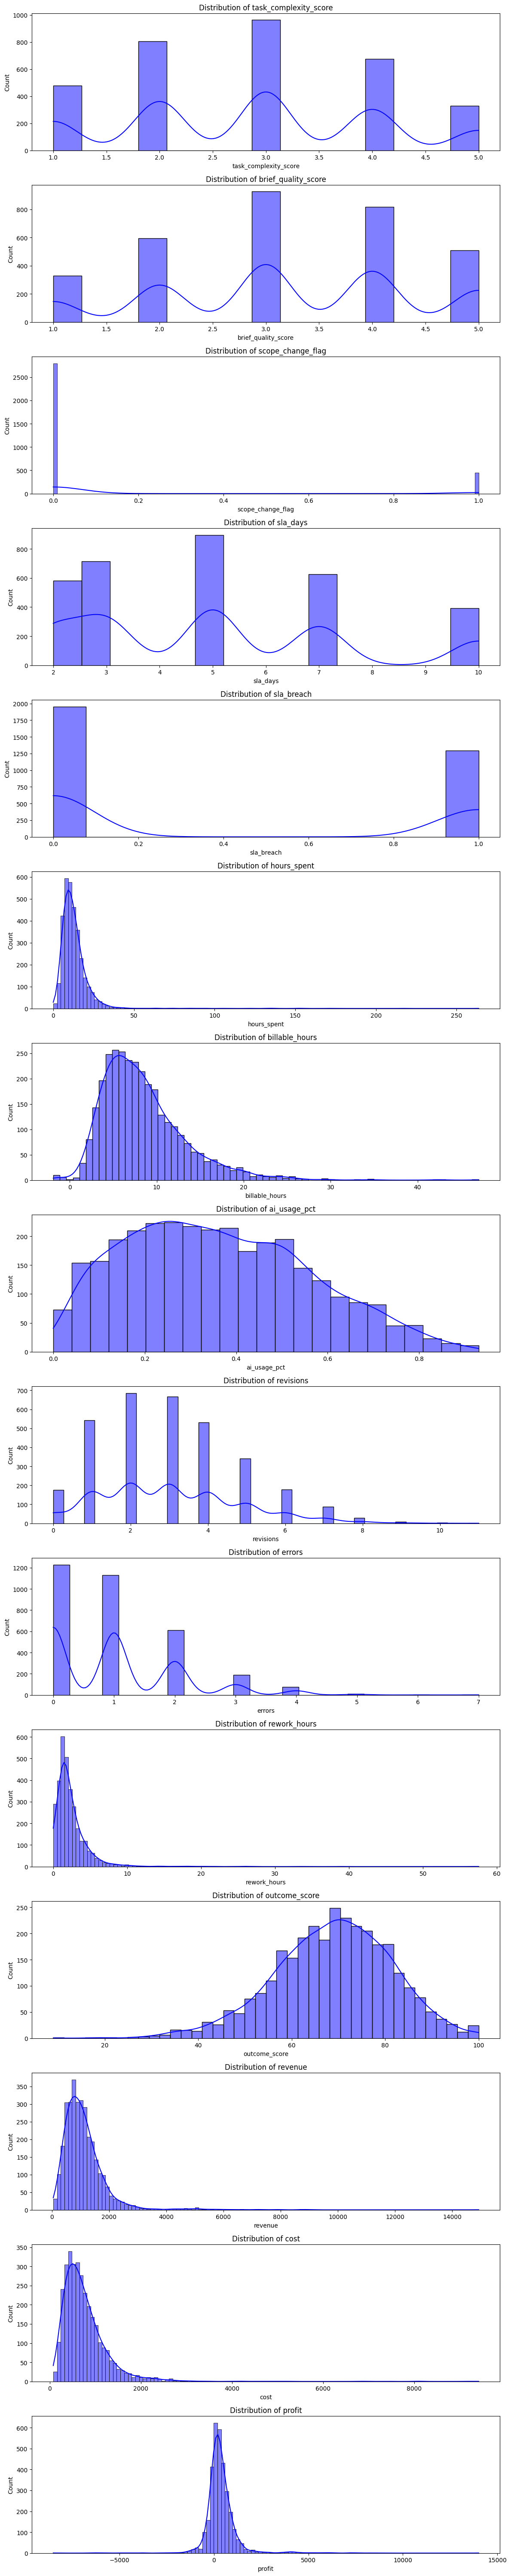

In [164]:
# Create the figure and axes
fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4 * len(num_cols)))

# Loop through columns AND the axes index
for i, col in enumerate(num_cols):
    # Pass the specific axis 'axes[i]' to the ax parameter
    sns.histplot(df_productivity[col], kde=True, color='blue', label='All Data', ax=axes[i])
    
    # Optional but recommended: Add a title so you know which plot is which
    axes[i].set_title(f'Distribution of {col}')

# Adjust layout so labels don't overlap
plt.tight_layout()

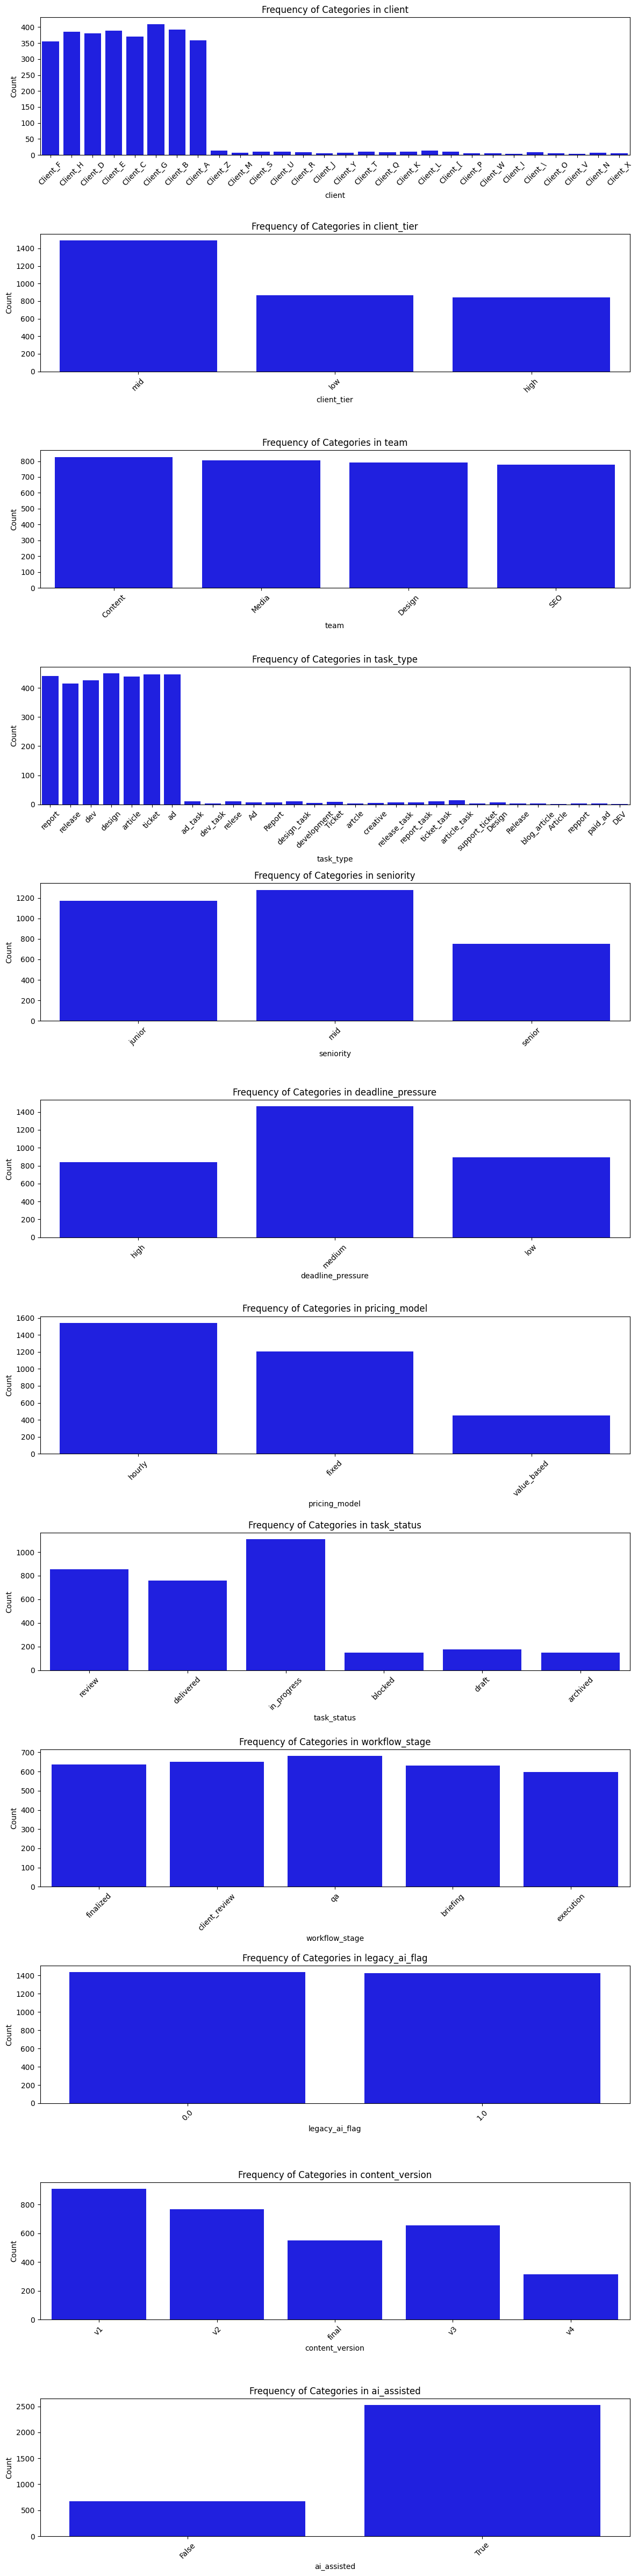

In [183]:
exclude_categories = ["task_id", "project_id", "created_at", "delivered_at", "created_by", "updated_at", "jira_ticket"]
cat_cols_filtered = [col for col in cat_cols if col not in exclude_categories]

# 3. Combine both lists into one so we can plot them all in a single loop
cols_to_plot = cat_cols_filtered + bool_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    # Pass the specific axis 'axes[i]' to the ax parameter
    sns.countplot(data=df_productivity, x=col, color='blue', ax=axes[i])
    
    axes[i].set_title(f'Frequency of Categories in {col}')
    axes[i].set_ylabel('Count')
    
    # Pro-tip: Categorical labels are often long text strings. 
    # Rotating them 45 degrees stops them from overlapping!
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout so labels don't overlap
plt.tight_layout()

### Duplicates Check

In [166]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [167]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [168]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)

In [169]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


#### Normalization of the "team" column

In [170]:
df_productivity['team'] = df_productivity['team'].str.strip()

print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))

df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)
print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']


In [171]:
print('\nDistribution:')
display(df_productivity['team'].value_counts(dropna=False).to_frame())


Distribution:


,count
team,
Content,827
Media,805
Design,790
SEO,778


#### Date Parsing

In [172]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")

# Creation of the column "duration_days"
df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

# Dealing with negative values of the "duration_days" column
mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")

print("\n-------")
print("Snapshot of the negative 'duration days' values:")

if neg_count > 0:
    print(f"\n{df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head()}")
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14

-------
Snapshot of the negative 'duration days' values:

     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0


In [173]:
print("\nduration_days:")
display(df_productivity['duration_days'].describe().round(1).to_frame())


duration_days:


,duration_days
count,3148.0
mean,4.5
std,1.8
min,0.0
25%,3.0
50%,5.0
75%,6.0
max,10.0


#### Cleaning of the `legacy_ai_flag` column

In [174]:
print("Before cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)
df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

Before cleaning:


,count
legacy_ai_flag,
false,1436
true,1427
unknown,337



After cleaning:


,count
legacy_ai_flag,
0.0,1436
1.0,1427
NaN,337


#### Creation of the column `ai_indicator`

In [175]:
ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")


Correlation with AI usage indicator: -0.014


### Data Cleaning Summary (Duplicates & Feature Engineering)

Based on the execution of the previous sections, the following data preprocessing and cleaning steps were implemented to ensure consistency and reliability:

#### 1. Deduplication
We identified **48 duplicate observations** sharing the same `task_id`. To resolve this natively, the records were sorted by their `updated_at` timestamp, and the most recent entry was preserved (guaranteeing the latest task status is used). Post-processing confirmed that 0 duplicates remain.

#### 2. Normalization of the `team` Column
The `team` column contained typos and inconsistent casing (e.g., 'Contennt', 'Paid Media', 'DESIGN'). By stripping whitespace, converting text to lowercase, and mapping variations to a unified nomenclature, the column was synthesized into exactly **4 distinct teams** with a well-balanced distribution:
- **Content**: 827 tasks
- **Media**: 805 tasks
- **Design**: 790 tasks
- **SEO**:   778 tasks

#### 3. Date Parsing & Task Duration Calculation
The timestamps `created_at` and `delivered_at` were successfully cast to datetime objects (resulting in 0 missing values for creation dates and 38 `NaT` for delivery). 
A new engineered feature, **`duration_days`**, was created to track end-to-end task time. During validity checks, **14 negative durations** were discovered,likely representing data entry errors or misaligned timestamps, and were appropriately replaced with `NaN`. The cleaned `duration_days` feature now correctly spans from 0 to 10 days, with a mean task duration of 4.5 days.

#### 4. Standardizing the `legacy_ai_flag`
This column originally consisted of lowercase, capitalized, and 'unknown' string values. It was standardized into a clean numeric format (1.0 for True, 0.0 for False). The 'unknown' flags were explicitly cast to `NaN` to reflect missing data accurately without skewing analyses. The final distribution shows a balanced historical split: 1,436 tasks categorized as False vs. 1,427 tasks as True (with 337 missing values).
#### 5. Creation of the `ai_indicator`
To further investigate the real adoption of AI, we engineered a binary feature `ai_indicator` based on whether `ai_usage_pct` was strictly greater than 0%. A distinct correlation check between this new indicator and the `legacy_ai_flag` revealed a correlation of **-0.014**, indicating virtually zero relationship. This unexpectedly implies that tasks flagged as historically using 'legacy' AI tools do not necessarily align with current, quantifiable AI engagement levels.

#### Handling missing values

In [176]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

legacy_ai_flag         337
jira_ticket            331
ai_usage_pct           143
outcome_score          132
billable_hours          81
rework_hours            72
brief_quality_score     68
duration_days           52
delivered_at            38
sla_days                34
dtype: int64

In [177]:

missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
missing_pct.sort_values(ascending=False)

legacy_ai_flag           10.53125
jira_ticket              10.34375
ai_usage_pct              4.46875
outcome_score             4.12500
billable_hours            2.53125
rework_hours              2.25000
brief_quality_score       2.12500
duration_days             1.62500
delivered_at              1.18750
sla_days                  1.06250
task_id                   0.00000
project_id                0.00000
client                    0.00000
task_complexity_score     0.00000
deadline_pressure         0.00000
scope_change_flag         0.00000
client_tier               0.00000
task_type                 0.00000
team                      0.00000
sla_breach                0.00000
hours_spent               0.00000
created_at                0.00000
pricing_model             0.00000
seniority                 0.00000
errors                    0.00000
revisions                 0.00000
ai_assisted               0.00000
profit                    0.00000
cost                      0.00000
revenue       

<Axes: >

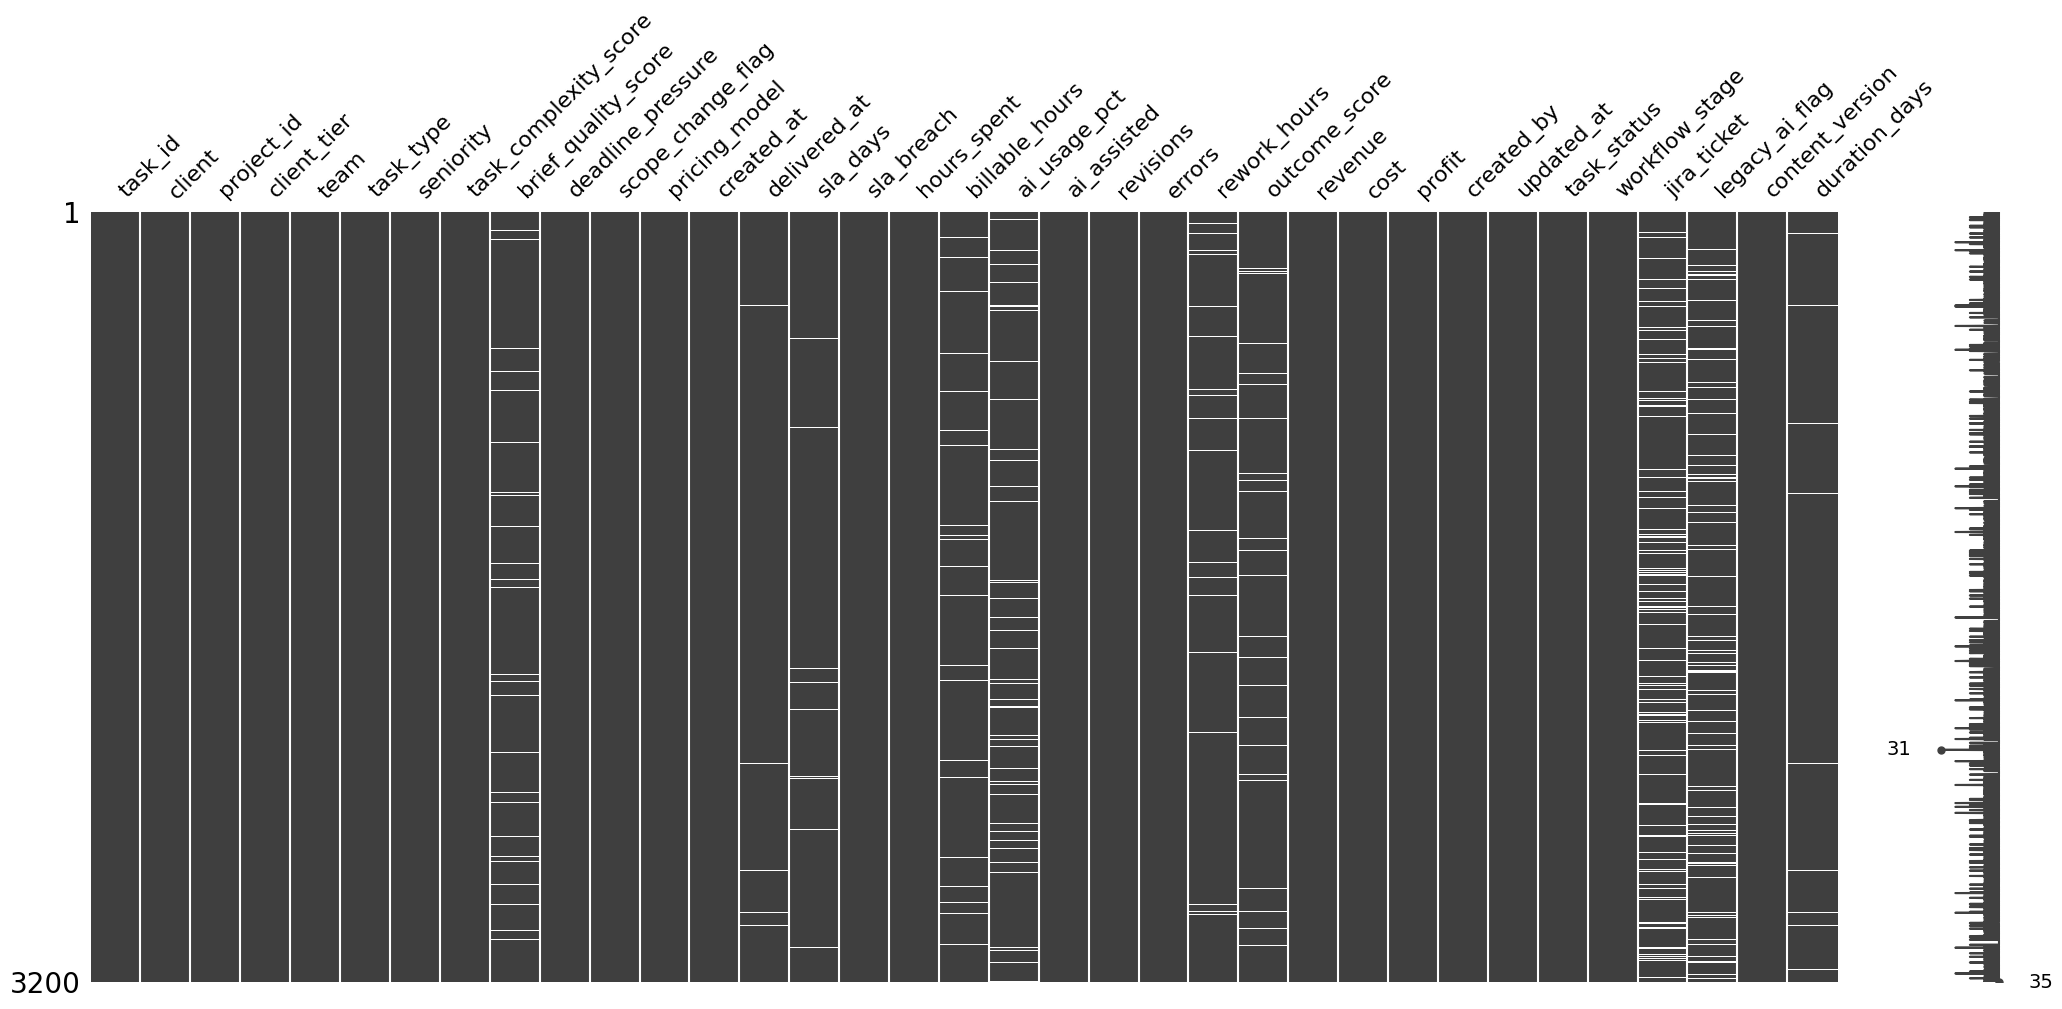

In [178]:
msno.matrix(df_productivity)

## Target Variable : Profit

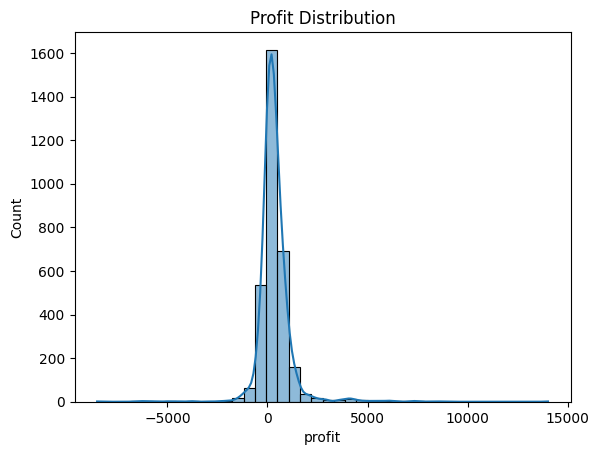

In [179]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()